# Why ensembles win: from majority votes to random forests

**NS5007 Human and Artificial Intelligence · lab notebook**

Plan for today: train three ordinary classifiers on real breast-cancer scans, combine them with a majority vote, then run three tiny simulations that show *why* the combination wins. We finish with the industrial versions - bagging, random forests, boosting - and sabotage experiments.

On Google Colab: `Runtime > Run all`. Only numpy, matplotlib and scikit-learn are needed (preinstalled); the free CPU runtime completes in well under 5 minutes. Exercises (**Ex 1-4**) are marked with TODOs - solutions sit collapsed at the bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

rng = np.random.default_rng(0)


def plot_classifier(ax, model, title=""):
    """Draw the model's decision regions on the 2 training features (uses globals X_tr, y_tr)."""
    x0, x1 = X_tr[:, 0].min(), X_tr[:, 0].max()
    y0, y1 = X_tr[:, 1].min(), X_tr[:, 1].max()
    px, py = 0.08 * (x1 - x0), 0.08 * (y1 - y0)
    xx, yy = np.meshgrid(np.linspace(x0 - px, x1 + px, 250),
                         np.linspace(y0 - py, y1 + py, 250))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.35,
                colors=["#f2c4c4", "#cfe6d4"])
    for label, color, name in [(0, "#c44e52", "malignant"), (1, "#55a868", "benign")]:
        ax.scatter(*X_tr[y_tr == label].T, c=color, s=14, alpha=0.55, lw=0, label=name)
    ax.set(xlabel=F1, ylabel=F2, title=title)
    ax.legend(frameon=False, fontsize=8, loc="best")


print("ready")

ready


## The data: 569 breast-tumour scans

Each tumour has 30 measurements; the label says whether it was malignant (0) or benign (1). For Part 1-2 we keep just two of the most informative features (*mean concavity* and *worst area*) so that decision boundaries can be drawn on paper.

train: (426, 2) | test: (143, 2)


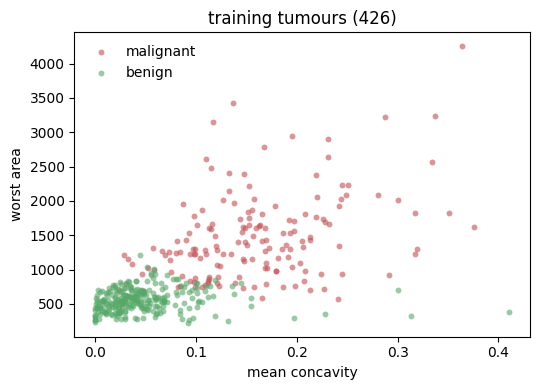

In [2]:
data = load_breast_cancer()
Xa, ya = data.data, data.target          # 569 tumours, 30 features; 1 = benign

F1, F2 = "mean concavity", "worst area"
cols = [list(data.feature_names).index(f) for f in (F1, F2)]

Xa_tr, Xa_te, y_tr, y_te = train_test_split(
    Xa, ya, test_size=0.25, stratify=ya, random_state=2)

X_tr, X_te = Xa_tr[:, cols], Xa_te[:, cols]   # two-feature versions for Parts 1-2
Xa_tr, Xa_te                                  # full-feature versions for Parts 3-4 (no-op peek)

fig, ax = plt.subplots(figsize=(5.5, 4))
for label, color, name in [(0, "#c44e52", "malignant"), (1, "#55a868", "benign")]:
    ax.scatter(*X_tr[y_tr == label].T, c=color, s=18, alpha=0.6, lw=0, label=name)
ax.set(xlabel=F1, ylabel=F2, title=f"training tumours ({len(y_tr)})")
ax.legend(frameon=False)
plt.tight_layout()

print("train:", X_tr.shape, "| test:", X_te.shape)

## Part 1 - three individuals

Three classifiers that learn in completely different ways: a weighted straight-line rule (logistic regression), memorised neighbours (kNN), and yes/no questions arranged in a tree. Train them and look at their decision boundaries.

In [3]:
models = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)),
    "k-nearest neighbors": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=9)),
    "decision tree": DecisionTreeClassifier(random_state=0),   # deliberately unrestricted
}

pred_single, acc_single = {}, {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    pred_single[name] = m.predict(X_te)
    acc_single[name] = float((pred_single[name] == y_te).mean())
    print(f"{name:22s} {acc_single[name]:.3f}")

logistic regression    0.951
k-nearest neighbors    0.944
decision tree          0.937


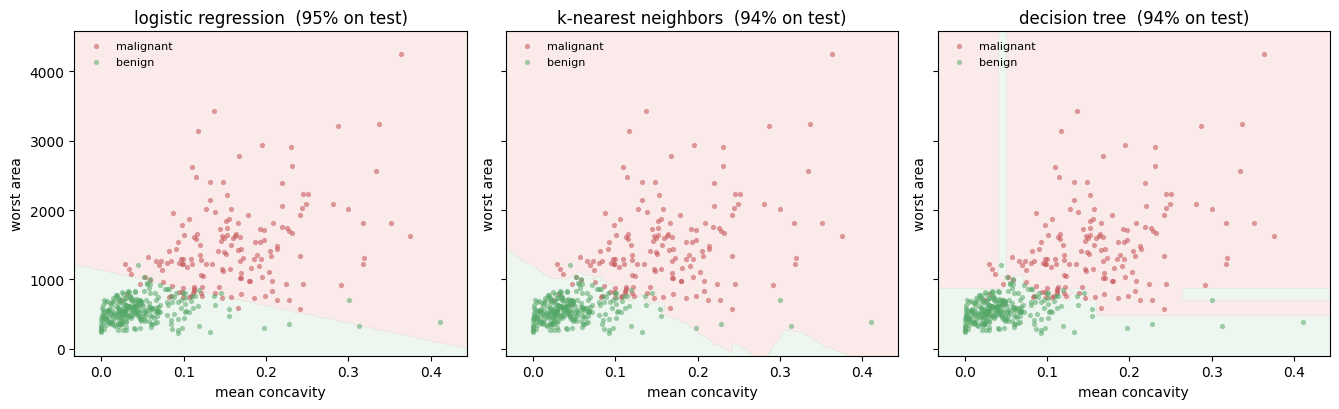

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharex=True, sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    plot_classifier(ax, m, title=f"{name}  ({acc_single[name]:.0%} on test)")
plt.tight_layout()

All three clear ~85%, none is great, and the tree's boundary is visibly carved around individual training points. Does the tree *itself* know something the others don't, or did it just get lucky fitting noise?

## Ex 1 - how much does one tree wobble?

Refit the tree 40 times, each time on a **random half** of the training set, and count how many test points ever change their predicted label between refits. Then guess before trying: would the same experiment make logistic regression flip too?

In [5]:
B = 40
votes_tree = np.zeros((B, len(y_te)), dtype=int)

for b in range(B):
    # TODO 1: sample half of the training row indices without replacement
    # (hint: rng.choice(len(y_tr), size=len(y_tr) // 2, replace=False))
    # TODO 2: fit a fresh DecisionTreeClassifier(random_state=b) on those rows only
    # TODO 3: store its test predictions in votes_tree[b]
    pass

wobbly = (votes_tree.std(axis=0) > 0).mean()
print(f"{wobbly:.0%} of test points flip when the tree is retrained")

0% of test points flip when the tree is retrained


## Part 2 - the cheapest ensemble: a majority vote

Three friends who are each right ~90% of the time can do better *together*, as long as they are wrong in different places. Stack their predictions and let every test point be decided by majority rule - no sklearn machinery, just counting.

In [6]:
P = np.column_stack([pred_single[name] for name in models])   # shape: (n_test, 3)
hard_vote = (P == 1).sum(axis=1) >= 2                          # at least 2 of 3 say benign
acc_hard = float((hard_vote.astype(int) == y_te).mean())

print("--- the lineup -------------------------------------")
for n, a in zip(list(models) + ["hard majority vote"],
                list(acc_single.values()) + [acc_hard]):
    print(f"{n:22s} {a:.3f}")

--- the lineup -------------------------------------
logistic regression    0.951
k-nearest neighbors    0.944
decision tree          0.937
hard majority vote     0.958


**Ex 2 - soft voting**

A hard vote treats every classifier alike, even when one mutters 0.51 and another shouts 0.99. Fix: average the predicted *probabilities* and threshold at 0.5 ("soft voting").

Write it yourself - your number should agree with the `VotingClassifier` check underneath.

In [7]:
proba = [models[name].predict_proba(X_te)[:, 1] for name in models]

# TODO 1: average the three probability vectors into one
# TODO 2: threshold the average at 0.5 to get labels, and print the test accuracy
avg_p = ...

In [8]:
from sklearn.ensemble import VotingClassifier

vc_soft = VotingClassifier(list(models.items()), voting="soft").fit(X_tr, y_tr)
vc_hard = VotingClassifier(list(models.items()), voting="hard").fit(X_tr, y_tr)
print(f"check  sklearn soft: {(vc_soft.predict(X_te) == y_te).mean():.3f}   "
      f"sklearn hard: {(vc_hard.predict(X_te) == y_te).mean():.3f}")

check  sklearn soft: 0.958   sklearn hard: 0.958


## Part 3 - why does combining help?

So far the vote is an empirical party trick. Real ensembles rest on three ingredients, which three toy simulations isolate: members must beat chance (1), disagree usefully (2), and averaging washes out variance (3).

### Sim 1 - juries of mediocre voters

Every juror answers an endless stream of yes/no questions correctly with probability $p$, independently. The committee answers by majority. Watch its accuracy as the committee grows.

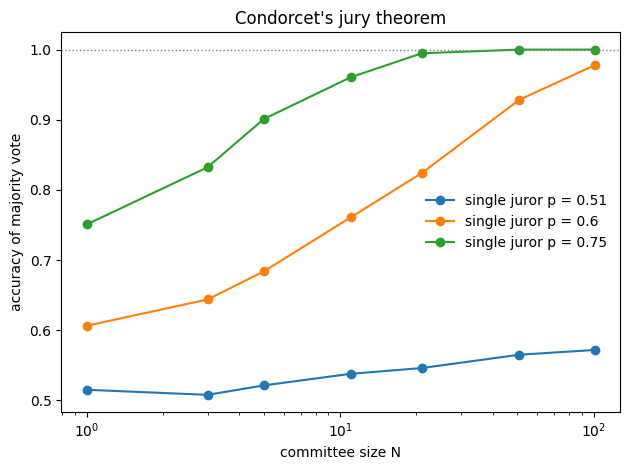

In [9]:
def jury_accuracy(p, n_voters, trials=4000):
    correct = rng.random((trials, n_voters)) < p           # did each juror get it right?
    return (correct.sum(axis=1) > n_voters / 2).mean()     # strict majority right?

ns = [1, 3, 5, 11, 21, 51, 101]
for p in [0.51, 0.60, 0.75]:
    accs = [jury_accuracy(p, n) for n in ns]
    plt.plot(ns, accs, marker="o", label=f"single juror p = {p}")

plt.axhline(1.0, ls=":", c="grey", lw=1)
plt.xscale("log")
plt.xlabel("committee size N")
plt.ylabel("accuracy of majority vote")
plt.title("Condorcet's jury theorem")
plt.legend(frameon=False)
plt.tight_layout()

Jurors who are barely better than a coin toss form committees that are almost never wrong. This is Condorcet's jury theorem (1785) - the mathematics behind "wisdom of crowds". A fair coin ($p$ = 0.5) would sit flat at 0.5 forever: averaging amplifies signal only where some already exists.

**Ex 3 - when does voting hurt?**

Below $p$ = 0.5 the magic reverses. Map the majority accuracy (fix N = 101) against $p$ from 0.35 to 0.65, and find where the committee stops beating its own members.

In [10]:
ps = np.linspace(0.35, 0.65, 31)
N = 101

# TODO 1: compute the majority accuracy for every p in ps
maj = ...

# TODO 2: plot maj against ps; add the grey dashed diagonal ps vs ps (= single juror)
# so the region where the committee helps and the region where it hurts are visible
# TODO 3: print the p where the two lines cross

### Sim 2 - the mistakes must not repeat

Hidden in the jury story was a second ingredient: *independence*. If members copy each other, three judges are one judge with three chairs. Here three voters are each wrong with probability $q$; the dial $\rho$ sets what share of their errors they make **together**. With 2 classes, being wrong means picking the same single alternative, so the committee fails whenever at least 2 of 3 slip.

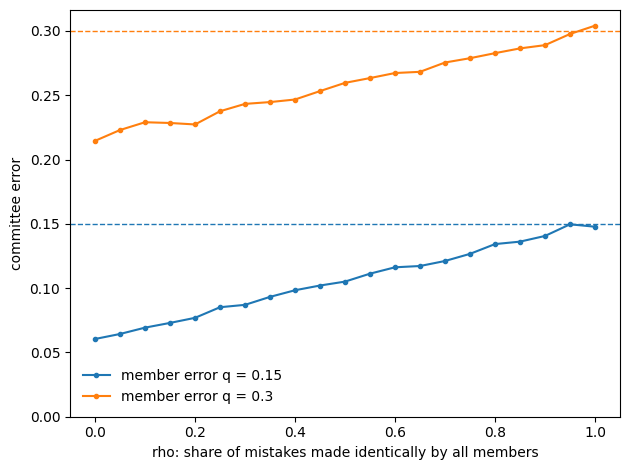

In [11]:
def committee_error(q, rho, trials=40_000):
    solo_err  = rng.random((trials, 1)) < q          # one error event, shown to all
    indep_err = rng.random((trials, 3)) < q          # three private error events
    err = np.where(rng.random((trials, 1)) < rho,    # with prob rho use the shared event,
                   solo_err, indep_err)              # otherwise everyone errs alone
    return (err.sum(axis=1) >= 2).mean()             # committee wrong iff >= 2 of 3 wrong

rhos = np.linspace(0, 1, 21)
for q in [0.15, 0.30]:
    errs = [committee_error(q, r) for r in rhos]
    line, = plt.plot(rhos, errs, marker=".", label=f"member error q = {q}")
    plt.axhline(q, ls="--", lw=1, color=line.get_color())

plt.xlabel("rho: share of mistakes made identically by all members")
plt.ylabel("committee error")
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.tight_layout()

Read left to right: at $\rho$ = 0 errors are private, the committee almost never gets ganged up on, and its error collapses far below any member's. At $\rho$ = 1 all three stumble together, the vote adds nothing, and the curve meets the dashed solo-error line. Everything an ensemble gains lives in the gap between those extremes - and decorrelation is exactly what bootstrapping and random feature subsets buy us.

### Sim 3 - averaging tames a wild learner

Back to the tumours, now with all 30 features. Fit deep unpruned trees (the wobbliest learners we have) on **bootstrap resamples** of the training set, and average their predicted probabilities as more of them join.

a lone bootstrap clone starts at 0.916 - no better than the plain full-data tree (0.916) - yet averaging 120 of them reached 0.979


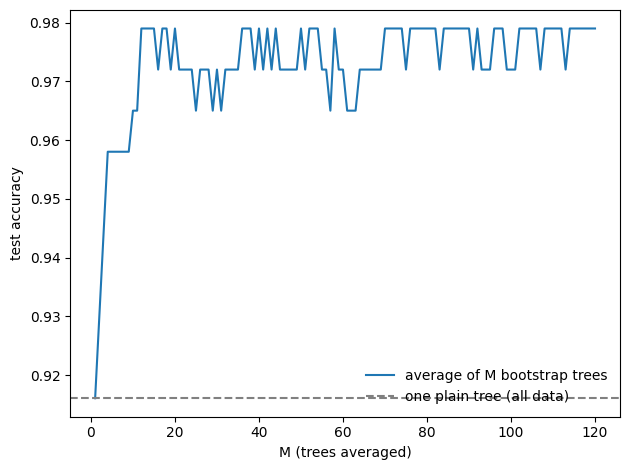

In [12]:
M = 120
prob_sum = np.zeros(len(y_te))
ms, accs = [], []
for b in range(M):
    rows = rng.integers(0, len(y_tr), len(y_tr))              # bootstrap resample
    t = DecisionTreeClassifier(random_state=b).fit(Xa_tr[rows], y_tr[rows])
    prob_sum += t.predict_proba(Xa_te)[:, 1]
    ms.append(b + 1)
    accs.append(((prob_sum / (b + 1) > 0.5).astype(int) == y_te).mean())

acc_plain_tree = float((DecisionTreeClassifier(random_state=0)
                        .fit(Xa_tr, y_tr).predict(Xa_te) == y_te).mean())

plt.plot(ms, accs, label="average of M bootstrap trees")
plt.axhline(acc_plain_tree, ls="--", c="grey", label="one plain tree (all data)")
plt.xlabel("M (trees averaged)")
plt.ylabel("test accuracy")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()

print(f"a lone bootstrap clone starts at {accs[0]:.3f} - no better than the plain "
      f"full-data tree ({acc_plain_tree:.3f}) - yet averaging {M} of them reached {accs[-1]:.3f}")

Each member saw a *distorted, shrunken* dataset and is worse than the plain tree - yet their average beats it comfortably. The wobble you measured in Ex 1 is variance, and averaging is what removes it. Bootstrap + average has a name: **bagging**. Random forests push one step further, and boosting recycles the idea sequentially.

## Part 4 - the machine room

Same data, three off-the-shelf ensembles: `BaggingClassifier` (literally the last simulation), `RandomForestClassifier` (bagging plus a random subset of features considered at each split), and gradient boosting (trees grown one after another, each repairing the errors of the ones before).

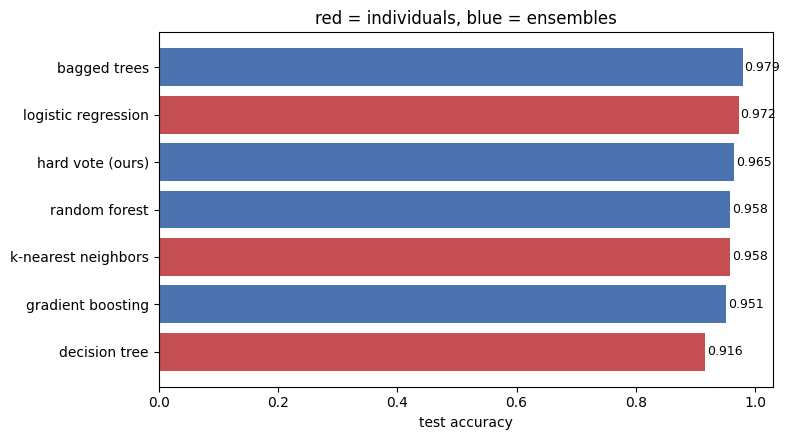

In [13]:
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              HistGradientBoostingClassifier)

trio = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)),
    "k-nearest neighbors": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "decision tree": DecisionTreeClassifier(random_state=0),
}
ensembles = {
    "hard vote (ours)": VotingClassifier(list(trio.items()), voting="hard"),
    "bagged trees": BaggingClassifier(DecisionTreeClassifier(random_state=0),
                                      n_estimators=120, random_state=0),
    "random forest": RandomForestClassifier(n_estimators=120, random_state=0),
    "gradient boosting": HistGradientBoostingClassifier(random_state=0),
}

final_acc = {}
for group in (trio, ensembles):
    for name, mdl in group.items():
        mdl.fit(Xa_tr, y_tr)
        final_acc[name] = float((mdl.predict(Xa_te) == y_te).mean())

order = sorted(final_acc, key=final_acc.get)
colors = ["#c44e52" if n in trio else "#4c72b0" for n in order]
plt.figure(figsize=(8, 4.5))
plt.barh(order, [final_acc[n] for n in order], color=colors)
for n in order:
    plt.text(final_acc[n] + 0.003, n, f"{final_acc[n]:.3f}", va="center", fontsize=9)
plt.xlim(right=1.03)
plt.xlabel("test accuracy")
plt.title("red = individuals, blue = ensembles")
plt.tight_layout()

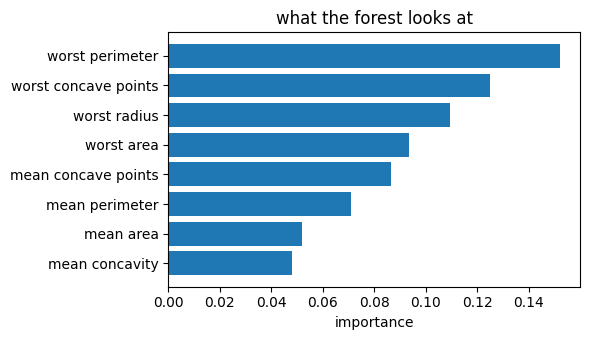

In [14]:
rf_imp = ensembles["random forest"].feature_importances_
top = np.argsort(rf_imp)[::-1][:8]

plt.figure(figsize=(6, 3.5))
plt.barh([data.feature_names[i] for i in top][::-1], rf_imp[top][::-1])
plt.xlabel("importance")
plt.title("what the forest looks at")
plt.tight_layout()

The bar chart shows two stories at once. Within the tree family the effect is textbook: a lonely tree scores lowest by far, and every averaging scheme lifts it several points to the top of the board. Meanwhile logistic regression ties with the vote near the ceiling - on this small, fairly clean dataset its straight-line family is already sufficient, and no amount of averaging removes that *bias*. Ensembles fix variance problems, not model-class limits.

### Stress test - what if the labels lie?

Real medical registries contain annotation mistakes. We corrupt **15% of the training labels** (test set stays clean) and refit everything. Predict first: which bars move most?

63 of 426 training labels are now wrong


fall from clean data:
  bagged trees           0.979 -> 0.937
  decision tree          0.916 -> 0.762
  gradient boosting      0.951 -> 0.944
  hard vote (ours)       0.965 -> 0.951
  k-nearest neighbors    0.958 -> 0.930
  logistic regression    0.972 -> 0.951
  random forest          0.958 -> 0.958


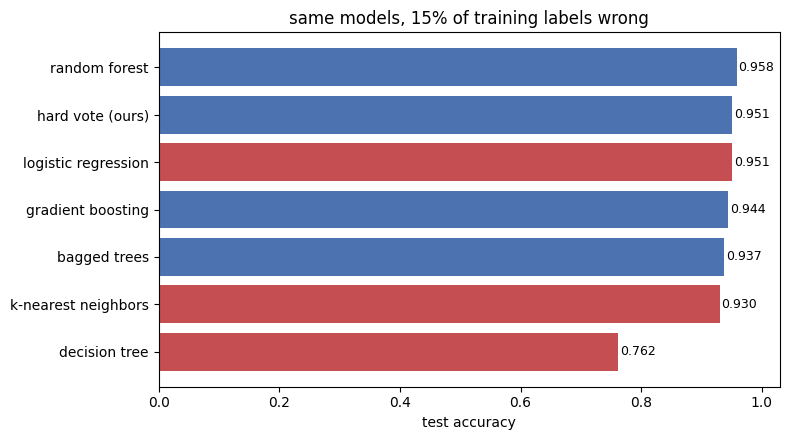

In [15]:
# corrupt the training labels, then refit everything on them
rng_noise = np.random.default_rng(7)
y_tr_noisy = y_tr.copy()
flip = rng_noise.random(len(y_tr_noisy)) < 0.15
y_tr_noisy[flip] = 1 - y_tr_noisy[flip]
print(f"{flip.sum()} of {len(y_tr_noisy)} training labels are now wrong")

acc_noisy = {}
for group in (trio, ensembles):
    for name, mdl in group.items():
        mdl.fit(Xa_tr, y_tr_noisy)                       # refit on corrupted labels
        acc_noisy[name] = float((mdl.predict(Xa_te) == y_te).mean())

order = sorted(acc_noisy, key=acc_noisy.get)
colors = ["#c44e52" if n in trio else "#4c72b0" for n in order]
plt.figure(figsize=(8, 4.5))
plt.barh(order, [acc_noisy[n] for n in order], color=colors)
for n in order:
    plt.text(acc_noisy[n] + 0.003, n, f"{acc_noisy[n]:.3f}", va="center", fontsize=9)
plt.xlim(right=1.03)
plt.xlabel("test accuracy")
plt.title("same models, 15% of training labels wrong")
plt.tight_layout()

print("fall from clean data:")
for n in sorted(final_acc):
    print(f"  {n:22s} {final_acc[n]:.3f} -> {acc_noisy[n]:.3f}")

A single deep tree obeys every instruction it gets, including the mistakes - it memorises them and pays on test day. The forest dilutes each bogus label across 120 bootstrap-averaged trees, none of which saw it often enough to care. This robustness is the same variance-cancelling machinery as Sim 3, now shown against sabotage instead of sampling luck.

**Ex 4 - ruin the forest**

A forest wins because its 120 trees disagree about which feature to trust at each split; the default `max_features="sqrt"` forces each tree to consider only $\sqrt{30}\approx 5$. Predict first, then run: (a) letting every tree see all 30 features at every split, (b) turning off bootstrapping, (c) both. Which sabotage hurts most, and why doesn't the score collapse to the plain-tree baseline?

In [16]:
variants = {
    "default (sqrt)":      dict(),
    "all features":        dict(max_features=Xa_tr.shape[1]),
    "no bootstrap":        dict(bootstrap=False),
    "both sabotages":      dict(max_features=Xa_tr.shape[1], bootstrap=False),
}
print(f"reference random forest: {final_acc['random forest']:.3f}")

for tag, kw in variants.items():
    # TODO: build RandomForestClassifier(n_estimators=120, random_state=0, **kw),
    #       fit it on the full training set, and print the test accuracy next to tag
    ...

reference random forest: 0.958


## Wrap-up

1. An ensemble works when its members are **better than chance** (Sim 1) and **wrong in different places** (Sim 2). Granted those, averaging cancels variance - across datasets (Sim 3) *and* inside the data (corrupted labels) - while leaving model-class bias untouched.
2. Hard/soft voting, bagging and random forests are rungs on one ladder: more averaging, plus more engineered disagreement. Boosting climbs sideways - sequential members specialise in predecessor's mistakes.
3. All of this depends on luck-free construction: bootstrap resampling, random feature subsets, fixed seeds. Correlated experts are just expensive copies of one expert.

People organise themselves into ensembles all the time - juries, medicine panels, the wisdom of crowds. So do brains: thousands of individually unreliable neurons voting together emit a dependable signal.

| term | one-liner |
|---|---|
| variance | how much predictions shift when training data shifts |
| bootstrap | resample rows with replacement, so every member sees a slightly different dataset |
| bagging | bootstrap + aggregate: many wobbly learners, one average |
| decorrelation | engineering disagreement between members (here: random feature subsets) |
| boosting | grow members sequentially; each fixes what the others got wrong |

### Solutions

<details><summary><b>Ex 1</b></summary>

```python
B = 40
votes_tree = np.zeros((B, len(y_te)), dtype=int)
for b in range(B):
    rows = rng.choice(len(y_tr), size=len(y_tr) // 2, replace=False)
    clf = DecisionTreeClassifier(random_state=b).fit(X_tr[rows], y_tr[rows])
    votes_tree[b] = clf.predict(X_te)

wobbly = (votes_tree.std(axis=0) > 0).mean()
print(f"decision tree:       {wobbly:.0%} of test points flip")

# logistic regression for comparison: far fewer flips, it is the low-variance model here
votes_lr = np.zeros((B, len(y_te)), dtype=int)
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
for b in range(B):
    rows = rng.choice(len(y_tr), size=len(y_tr) // 2, replace=False)
    votes_lr[b] = pipe.fit(X_tr[rows], y_tr[rows]).predict(X_te)
print(f"logistic regression: {(votes_lr.std(axis=0) > 0).mean():.0%} of test points flip")
```

</details>

<details><summary><b>Ex 2</b></summary>

```python
proba = [models[name].predict_proba(X_te)[:, 1] for name in models]
avg_p = np.mean(proba, axis=0)                    # TODO 1 done
soft_vote = (avg_p > 0.5).astype(int)             # TODO 2 done
acc_soft = float((soft_vote == y_te).mean())
print(f"soft majority vote    {acc_soft:.3f}")

# soft and hard usually agree when members are confident and broadly correct;
# soft pulls ahead when members have informative confidence differences -
# e.g. a 90%-sure KNN should outweigh a muttering 51%-sure neighbour.
```

</details>

<details><summary><b>Ex 3</b></summary>

```python
ps = np.linspace(0.35, 0.65, 31)
N = 101
maj = [jury_accuracy(p, N) for p in ps]

plt.plot(ps, maj, label="majority of 101")
plt.plot(ps, ps, "--", c="grey", label="single juror")
crossing = ps[np.argmin(np.abs(np.array(maj) - ps))]
plt.axvline(crossing, ls=":", c="k")
plt.xlabel("individual juror accuracy p")
plt.ylabel("accuracy")
plt.legend(frameon=False)
print(f"the lines cross near p = {crossing:.2f}: above it, voting helps;")
print("below it, a committee entrenches the shared mistake.")
```

</details>

<details><summary><b>Ex 4</b></summary>

```python
for tag, kw in variants.items():
    rf_sabotage = RandomForestClassifier(n_estimators=120, random_state=0, **kw)
    rf_sabotage.fit(Xa_tr, y_tr)
    acc = float((rf_sabotage.predict(Xa_te) == y_te).mean())
    print(f"  {tag:22s} {acc:.3f}")

# With all features visible every tree chases the same few dominant ones, so the
# trees converge and the benefit shrinks toward the single-tree baseline.
# Bootstrapping still provides some diversity even then, which is why the score
# sags but does not collapse outright.
```

</details>